
# Complete Pandas Tutorial for Students

This notebook is designed for beginners learning:

- Pandas
- NumPy
- DataFrames
- Data Cleaning
- GroupBy
- Merge
- Pivot Tables
- Time Series
- Plotting

Each topic contains:
- Explanation
- Code
- Output understanding
- Practice-friendly structure



# 1. Import Required Libraries

We import:

- `pandas` → Data analysis
- `numpy` → Numerical operations
- `matplotlib` → Plotting graphs


In [65]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# 2. Creating Pandas Series

A Series is a 1-dimensional labeled array.

It is similar to:
- Python list
- Excel column


In [66]:

s1 = pd.Series(
    [10,20,30,40,50,60],
    index=['a','b','c','d','e','f']
)

print(s1)


a    10
b    20
c    30
d    40
e    50
f    60
dtype: int64



## Series from Dictionary

Dictionary keys become index labels.


In [67]:

s2 = pd.Series({
    'math': 85,
    'science': 92,
    'english': 78
})

print(s2)


math       85
science    92
english    78
dtype: int64



# 3. Creating DataFrames

A DataFrame is a 2-dimensional table.

Similar to:
- Excel sheet
- SQL table


In [68]:

data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Diana'],
    'Age': [25, 30, 35, 28],
    'City': ['NYC', 'LA', 'Chicago', 'NYC'],
    'Score': [85, 92, 78, 88]
}

df = pd.DataFrame(data)

print(df)


      Name  Age     City  Score
0    Alice   25      NYC     85
1      Bob   30       LA     92
2  Charlie   35  Chicago     78
3    Diana   28      NYC     88



## DataFrame from Tuples


In [69]:

df2 = pd.DataFrame(
    [(1, 'ram'), (2, 'shyam')],
    columns=['ID', 'name']
)

print(df2)


   ID   name
0   1    ram
1   2  shyam



# 4. File Operations (CSV & Excel)

Pandas can:
- Save CSV
- Read CSV
- Save Excel
- Read Excel


In [70]:

df.to_csv('students.csv', index=False)
print("CSV file saved")

df.to_excel('students.xlsx', index=False)
print("Excel file saved")


CSV file saved
Excel file saved



# 5. Basic Data Inspection

Useful functions:

- `head()` → first rows
- `tail()` → last rows
- `info()` → structure
- `describe()` → statistics


In [71]:

print(df.head(2))


    Name  Age City  Score
0  Alice   25  NYC     85
1    Bob   30   LA     92


In [72]:

print(df.tail(2))


      Name  Age     City  Score
2  Charlie   35  Chicago     78
3    Diana   28      NYC     88


In [73]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    4 non-null      object
 1   Age     4 non-null      int64 
 2   City    4 non-null      object
 3   Score   4 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 260.0+ bytes


In [74]:

print(df.describe())


             Age      Score
count   4.000000   4.000000
mean   29.500000  85.750000
std     4.203173   5.909033
min    25.000000  78.000000
25%    27.250000  83.250000
50%    29.000000  86.500000
75%    31.250000  89.000000
max    35.000000  92.000000


In [75]:

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Index:", df.index)


Shape: (4, 4)
Columns: ['Name', 'Age', 'City', 'Score']
Index: RangeIndex(start=0, stop=4, step=1)



# 6. Selecting Data

Methods:
- Brackets
- `loc`
- `iloc`
- Boolean filtering


In [76]:

print(df['Name'])


0      Alice
1        Bob
2    Charlie
3      Diana
Name: Name, dtype: object


In [77]:

print(df[['Name', 'Score']])


      Name  Score
0    Alice     85
1      Bob     92
2  Charlie     78
3    Diana     88


In [78]:

print(df.iloc[1])


Name     Bob
Age       30
City      LA
Score     92
Name: 1, dtype: object


In [79]:

print(df.loc[1])


Name     Bob
Age       30
City      LA
Score     92
Name: 1, dtype: object


In [80]:

print(df[1:4])


      Name  Age     City  Score
1      Bob   30       LA     92
2  Charlie   35  Chicago     78
3    Diana   28      NYC     88


In [81]:

print(df[df['Score'] > 85])


    Name  Age City  Score
1    Bob   30   LA     92
3  Diana   28  NYC     88



# 7. Handling Missing Data

Missing values are represented using:
- `NaN`


In [82]:

df_nan = pd.DataFrame({
    'A': [1, 2, np.nan, 4],
    'B': [5, np.nan, np.nan, 8],
    'C': [9, 10, 11, 12]
})

print(df_nan)


     A    B   C
0  1.0  5.0   9
1  2.0  NaN  10
2  NaN  NaN  11
3  4.0  8.0  12


In [83]:

print(df_nan.isnull())


       A      B      C
0  False  False  False
1  False   True  False
2   True   True  False
3  False  False  False


In [84]:

print(df_nan.isnull().any())


A     True
B     True
C    False
dtype: bool


In [85]:

print(df_nan.dropna())


     A    B   C
0  1.0  5.0   9
3  4.0  8.0  12


In [86]:

print(df_nan.fillna(0))


     A    B   C
0  1.0  5.0   9
1  2.0  0.0  10
2  0.0  0.0  11
3  4.0  8.0  12


In [87]:

df_nan['A'] = df_nan['A'].fillna(
    df_nan['A'].mean()
)

print(df_nan)


          A    B   C
0  1.000000  5.0   9
1  2.000000  NaN  10
2  2.333333  NaN  11
3  4.000000  8.0  12



# 8. Operations on Data

We can:
- Create new columns
- Apply functions
- Perform vectorized operations


In [88]:

df['Bonus'] = df['Score'] * 0.1

print(df)


      Name  Age     City  Score  Bonus
0    Alice   25      NYC     85    8.5
1      Bob   30       LA     92    9.2
2  Charlie   35  Chicago     78    7.8
3    Diana   28      NYC     88    8.8


In [89]:

df['Score_Squared'] = df['Score'].apply(
    lambda x: x**2
)

print(df[['Score', 'Score_Squared']])


   Score  Score_Squared
0     85           7225
1     92           8464
2     78           6084
3     88           7744


In [90]:

df['Age_Next_Year'] = df['Age'] + 1

print(df[['Age', 'Age_Next_Year']])


   Age  Age_Next_Year
0   25             26
1   30             31
2   35             36
3   28             29



# 9. GroupBy & Aggregation

Used for:
- Summary reports
- Business analytics
- Data grouping


In [91]:

grouped = df.groupby('City')['Score'].mean()

print(grouped)


City
Chicago    78.0
LA         92.0
NYC        86.5
Name: Score, dtype: float64


In [92]:

agg_df = df.groupby('City').agg({
    'Score': ['mean', 'max', 'min'],
    'Age': 'mean'
})

print(agg_df)


        Score           Age
         mean max min  mean
City                       
Chicago  78.0  78  78  35.0
LA       92.0  92  92  30.0
NYC      86.5  88  85  26.5


In [93]:

print(df.groupby('City').size())


City
Chicago    1
LA         1
NYC        2
dtype: int64



# 10. Merge & Concatenation

Similar to SQL JOIN operations.


In [94]:

df1 = pd.DataFrame({
    'ID': [1, 2, 3],
    'Name': ['Alice', 'Bob', 'Charlie']
})

df2 = pd.DataFrame({
    'ID': [1, 2, 4],
    'Score': [85, 92, 78]
})

merged = pd.merge(df1, df2, on='ID', how='inner')

print(merged)


   ID   Name  Score
0   1  Alice     85
1   2    Bob     92


In [95]:

left_merge = pd.merge(
    df1,
    df2,
    on='ID',
    how='left'
)

print(left_merge)


   ID     Name  Score
0   1    Alice   85.0
1   2      Bob   92.0
2   3  Charlie    NaN


In [96]:

concat_rows = pd.concat([df1, df1])

print(concat_rows)


   ID     Name
0   1    Alice
1   2      Bob
2   3  Charlie
0   1    Alice
1   2      Bob
2   3  Charlie



# 11. Pivot Tables & Crosstab

Used for:
- Summarizing data
- Business reporting
- Frequency analysis


In [97]:

sales = pd.DataFrame({
    'Date': ['2024-01-01', '2024-01-01',
             '2024-01-02', '2024-01-02'],
    'Product': ['A', 'B', 'A', 'B'],
    'Sales': [100, 150, 200, 130],
    'Region': ['East', 'West', 'East', 'West']
})

print(sales)


         Date Product  Sales Region
0  2024-01-01       A    100   East
1  2024-01-01       B    150   West
2  2024-01-02       A    200   East
3  2024-01-02       B    130   West


In [98]:

pivot = pd.pivot_table(
    sales,
    values='Sales',
    index='Product',
    columns='Region',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='Margin'
)

print(pivot)


Region   East  West  Margin
Product                    
A         300     0     300
B           0   280     280
Margin    300   280     580


In [99]:

crosstab = pd.crosstab(
    sales['Product'],
    sales['Region']
)

print(crosstab)


Region   East  West
Product            
A           2     0
B           0     2



# 12. Apply & Lambda Functions

Used for:
- Custom calculations
- Row-wise operations
- Data transformations


In [100]:

def grade(score):
    if score >= 90:
        return 'A'
    elif score >= 80:
        return 'B'
    else:
        return 'C'


In [101]:

df['Grade'] = df['Score'].apply(grade)

print(df[['Name', 'Score', 'Grade']])


      Name  Score Grade
0    Alice     85     B
1      Bob     92     A
2  Charlie     78     C
3    Diana     88     B


In [102]:

df['Sum_Cols'] = df[['Age', 'Score']].apply(
    lambda row: row['Age'] + row['Score'],
    axis=1
)

print(df[['Age', 'Score', 'Sum_Cols']])


   Age  Score  Sum_Cols
0   25     85       110
1   30     92       122
2   35     78       113
3   28     88       116



# 13. Time Series

Time series is data over time.


In [103]:

date_range = pd.date_range(
    start='2024-01-01',
    periods=2,
    

)

print(date_range)


DatetimeIndex(['2024-01-01', '2024-01-02'], dtype='datetime64[ns]', freq='D')


In [132]:
import datetime 

print(datetime.datetime.now())
print(datetime.date.today())


2026-05-22 11:02:49.939206
2026-05-22


In [ ]:

ts_df = pd.DataFrame(
    {'Value': [10, 20, 15, 30, 25]},
    index=date_range
)

print(ts_df)


            Value
2024-01-01     10
2024-01-02     20
2024-01-03     15
2024-01-04     30
2024-01-05     25


In [131]:
import pandas as pd

# 1. Define the date range first (matching the 4 rows of data)
date_range = pd.date_range(start="2026-05-22", periods=7, freq="D")


students = pd.DataFrame(
    {"Name": ["ram", "shyam", "Mohan", "roshan","golu","gopi",'sadfas']}, index=date_range
)

print(students)


              Name
2026-05-22     ram
2026-05-23   shyam
2026-05-24   Mohan
2026-05-25  roshan
2026-05-26    golu
2026-05-27    gopi
2026-05-28  sadfas


In [ ]:

print(ts_df.resample('2D').mean())


            Value
2024-01-01   15.0
2024-01-03   22.5
2024-01-05   25.0



# 14. Plotting

Pandas can create charts easily.


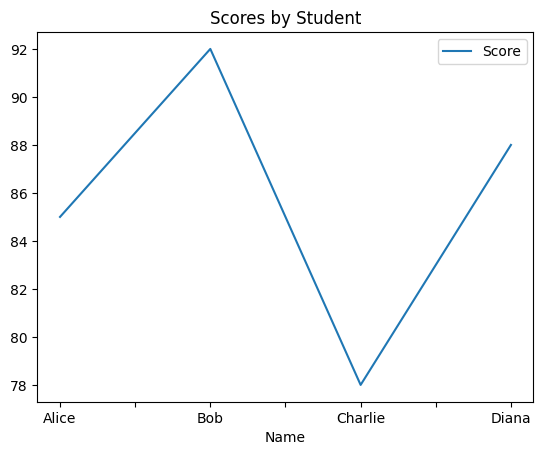

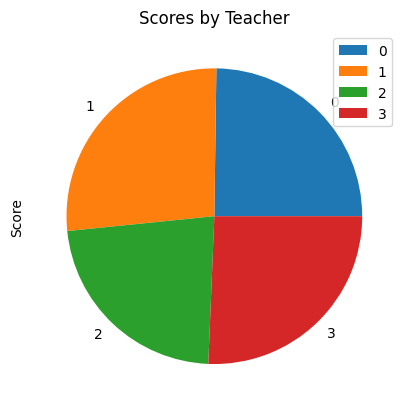

In [ ]:

df.plot(
    kind='line',
    x='Name',
    y='Score',
    title='Scores by Student'
)

df.plot(
    kind='pie',
    x='Name',
    y='Score',
    title='Scores by Teacher'
)

plt.show()




# 15. Sorting & Reset Index


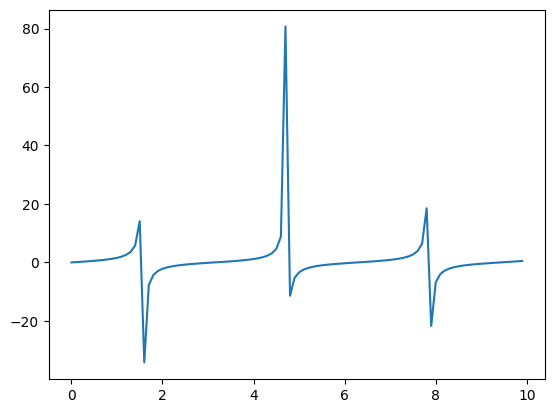

In [136]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 10, 0.1)
y = np.tan(x)
plt.plot(x, y)
plt.show()

In [138]:

df_sorted = df.sort_values(
    'Name',
    ascending=True
)

print(df_sorted)


      Name  Age     City  Score  Bonus  Score_Squared  Age_Next_Year Grade  \
0    Alice   25      NYC     85    8.5           7225             26     B   
1      Bob   30       LA     92    9.2           8464             31     A   
2  Charlie   35  Chicago     78    7.8           6084             36     C   
3    Diana   28      NYC     88    8.8           7744             29     B   

   Sum_Cols  
0       110  
1       122  
2       113  
3       116  


In [ ]:

filtered = df[df['Score'] > 80].reset_index(
    drop=True
)

print(filtered)


    Name  Age City  Score  Bonus  Score_Squared  Age_Next_Year Grade  Sum_Cols
0  Alice   25  NYC     85    8.5           7225             26     B       110
1    Bob   30   LA     92    9.2           8464             31     A       122
2  Diana   28  NYC     88    8.8           7744             29     B       116



# 16. Real-world Salary Example


In [139]:

salary_data = {
    'Employee': ['A', 'B', 'C', 'D'],
    'Salary': [25000, 30000, 40000, 50000],
    'Hike_Percentage': [12, 3, 7, 15]
}

salary_df = pd.DataFrame(salary_data)

salary_df['Increment_Amount'] = (
    salary_df['Salary']
    * salary_df['Hike_Percentage']
    / 100
)

salary_df['New_Salary'] = (
    salary_df['Salary']
    + salary_df['Increment_Amount']
)

print(salary_df)


  Employee  Salary  Hike_Percentage  Increment_Amount  New_Salary
0        A   25000               12            3000.0     28000.0
1        B   30000                3             900.0     30900.0
2        C   40000                7            2800.0     42800.0
3        D   50000               15            7500.0     57500.0



# Homework Exercises

## Exercise 1
Create a student DataFrame and:
- filter marks > 80
- sort descending

---

## Exercise 2
Create sales data and:
- use groupby
- create pivot table

---

## Exercise 3
Load a CSV file and:
- clean missing values
- save cleaned file

---

## Exercise 4
Create employee salary analysis:
- calculate increment
- calculate new salary



# Pandas Tutorial Completed

Students should now understand:

- Series
- DataFrames
- Indexing
- Missing Data
- GroupBy
- Merge
- Pivot Tables
- Time Series
- Plotting


In [ ]:
new_df=pd.DataFrame({
    "name":[''],
     "marks":['']
})